In [1]:
%load_ext autoreload
%autoreload 2

In [2]:

import numpy as np
from gecco import patient_data, calculate_spectrum_sp
from gecco.utils import nrrd_to_mhd
import os

phantom = patient_data.patient_phantom('/media/jericho/T7/Clinical_data/Pelvis/Pelvis_Prostate_Patient_5.nrrd', 1e10,is_fullfan=False)

# Source spectrum
spectrum = calculate_spectrum_sp(140,12)

# Beam filters
spectrum.filter('Be', 1.5)
spectrum.filter('Al', 2.75)
spectrum.filter('Ti', 0.89)

# Detector filters
spectrum.filter('Al', 3.7)
spectrum.filter('C', 3.8*(2/1.7)) # Difference in density

phantom.detector_material = 'CsI'
phantom.xx, phantom.yy = spectrum.get_points()
phantom.run_gecco(1e20,180,conv_on=False)


[2024-07-12 16:43:32,250] {utils.py:186} INFO - Using default geometry, DSD = 1510, nDetector = [512, 512], dDetector = [0.784, 0.784]
[2024-07-12 16:43:32,251] {utils.py:496} INFO - Loading density data from file
[2024-07-12 16:43:32,253] {utils.py:552} INFO - Loading attenuation files from /home/jericho/Software/gecco/gecco/data/user_phantoms/Pelvis_Prostate_Patient_5/Pelvis_Prostate_Patient_5_materials.txt
[2024-07-12 16:43:32,253] {utils.py:553} INFO - Making attenuation files in gecco:
[2024-07-12 16:43:32,253] {utils.py:557} INFO -     Air atten file already exists, skipping...
[2024-07-12 16:43:32,253] {utils.py:557} INFO -     polyurethane atten file already exists, skipping...
[2024-07-12 16:43:32,253] {utils.py:557} INFO -     teflon atten file already exists, skipping...
[2024-07-12 16:43:32,254] {utils.py:557} INFO -     pmp atten file already exists, skipping...
[2024-07-12 16:43:32,254] {utils.py:557} INFO -     bone50 atten file already exists, skipping...
[2024-07-12 16

In [12]:

phantom.correct_intensity(ml=False,crop=40)
phantom.interpolate_ggems_scatter()
phantom.calc_gecco_projections(scat_weight=0.01,noise_weight=1000) # Creates the gecco projections scatter to primary reduction from asg is 0.48 assumed half is taken by scatter correction



/home/jericho/Software/gecco/gecco/ggems_simulate.py:1314: RuntimeWarning: divide by zero encountered in log
  gecco_projections.append(- np.log((poisson.rvs(noise_weight*np.abs(


In [13]:
phantom.reconstruct_ggems('FDK')

/home/jericho/anaconda3/envs/tigre_fastcat/lib/python3.10/site-packages/pytigre-2.4.0-py3.10-linux-x86_64.egg/tigre/utilities/filtering.py:37: RuntimeWarning: invalid value encountered in multiply
  fproj=fproj*filt


In [14]:
import matplotlib.pyplot as plt
%pylab widget
import mpl_interactions as pli

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


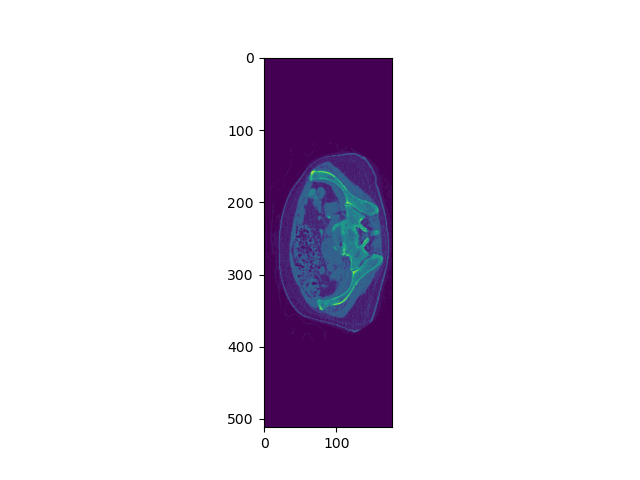

In [15]:
plt.figure()
pli.hyperslicer(phantom.phantom)

In [16]:
phantom.angles

array([0.        , 0.03490659, 0.06981317, 0.10471976, 0.13962634,
       0.17453293, 0.20943951, 0.2443461 , 0.27925268, 0.31415927,
       0.34906585, 0.38397244, 0.41887902, 0.45378561, 0.48869219,
       0.52359878, 0.55850536, 0.59341195, 0.62831853, 0.66322512,
       0.6981317 , 0.73303829, 0.76794487, 0.80285146, 0.83775804,
       0.87266463, 0.90757121, 0.9424778 , 0.97738438, 1.01229097,
       1.04719755, 1.08210414, 1.11701072, 1.15191731, 1.18682389,
       1.22173048, 1.25663706, 1.29154365, 1.32645023, 1.36135682,
       1.3962634 , 1.43116999, 1.46607657, 1.50098316, 1.53588974,
       1.57079633, 1.60570291, 1.6406095 , 1.67551608, 1.71042267,
       1.74532925, 1.78023584, 1.81514242, 1.85004901, 1.88495559,
       1.91986218, 1.95476876, 1.98967535, 2.02458193, 2.05948852,
       2.0943951 , 2.12930169, 2.16420827, 2.19911486, 2.23402144,
       2.26892803, 2.30383461, 2.3387412 , 2.37364778, 2.40855437,
       2.44346095, 2.47836754, 2.51327412, 2.54818071, 2.58308

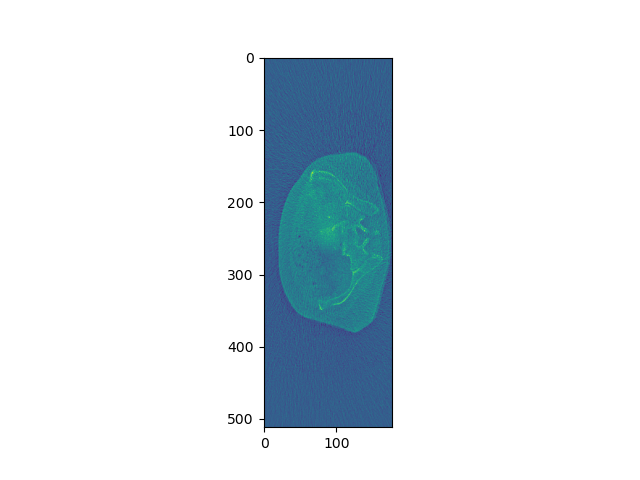

In [17]:
plt.figure()
pli.hyperslicer(phantom.img)

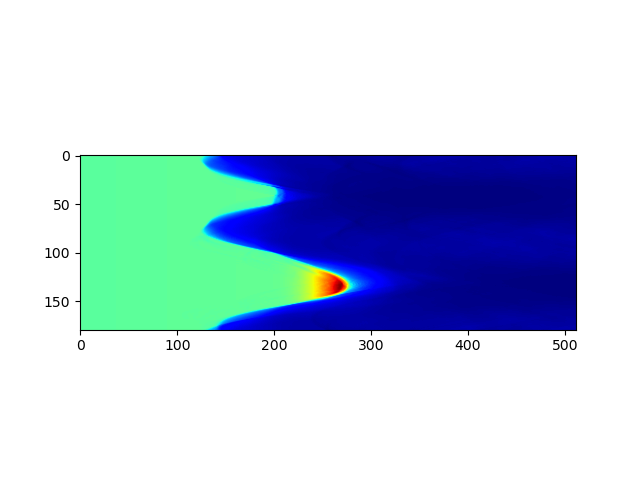

In [26]:
plt.figure()
plt.imshow(phantom.primary_projections[:,150,:],cmap='jet')

In [18]:
print(phantom.geomet)

TIGRE parameters
-----
Geometry parameters
Distance from source to detector (DSD) = 1510 mm
Distance from source to origin (DSO)= 1000.0 mm
-----
Detector parameters
Number of pixels (nDetector) = [512 512]
Size of each pixel (dDetector) = [0.784 0.784] mm
Total size of the detector (sDetector) = [401.408 401.408] mm
-----
Image parameters
Number of voxels (nVoxel) = [145 512 178]
Total size of the image (sVoxel) = [185.32102    654.374912   266.99899435] mm
Size of each voxel (dVoxel) = [1.278076   1.278076   1.49999435] mm
-----
Offset correction parameters
Offset of image from origin (offOrigin) = [0 0 0] mm
Offset of detector (offDetector) = [   0 -160] mm
-----
Auxillary parameters
Samples per pixel of forward projection (accuracy) = 0.5
-----
Rotation of the Detector (rotDetector) = [0 0 0] rad
